In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
international = pd.read_csv(r"C:\Users\shada\OneDrive\Desktop\python\International sale Report.csv")

In [3]:
international.head(30)

,index,DATE,Months,CUSTOMER,Style,SKU,Size,PCS,RATE,GROSS AMT
0,0,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-L,L,1.00,616.56,617.00
1,1,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-XL,XL,1.00,616.56,617.00
2,2,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-XXL,XXL,1.00,616.56,617.00
3,3,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5009,MEN5009-KR-L,L,1.00,616.56,617.00
4,4,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5011,MEN5011-KR-L,L,1.00,616.56,617.00
5,5,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5025,MEN5025-KR-L,L,1.00,649.03,649.00
6,6,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5015,MEN5015-KR-XL,XL,1.00,616.56,617.00
7,7,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5022,MEN5022-KR-XXL,XXL,1.00,649.03,649.00
8,8,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5014,MEN5014-KR-S,S,1.00,649.03,649.00
9,9,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5013,MEN5013-KR-S,S,1.00,649.03,649.00


In [4]:
international.columns

Index(['index', 'DATE', 'Months', 'CUSTOMER', 'Style', 'SKU', 'Size', 'PCS',
       'RATE', 'GROSS AMT'],
      dtype='object')

In [5]:
# doing basics column name cleaning
international.columns = international.columns.str.strip().str.lower()
international.columns

Index(['index', 'date', 'months', 'customer', 'style', 'sku', 'size', 'pcs',
       'rate', 'gross amt'],
      dtype='object')

In [6]:
international.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37432 entries, 0 to 37431
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   index      37432 non-null  int64 
 1   date       37431 non-null  object
 2   months     37407 non-null  object
 3   customer   36392 non-null  object
 4   style      36392 non-null  object
 5   sku        34958 non-null  object
 6   size       36392 non-null  object
 7   pcs        36392 non-null  object
 8   rate       36392 non-null  object
 9   gross amt  36392 non-null  object
dtypes: int64(1), object(9)
memory usage: 2.9+ MB


In [7]:
#doing renaming of one column name
international.rename(columns={"gross amt" : "amount"}, inplace =True)
international.columns

Index(['index', 'date', 'months', 'customer', 'style', 'sku', 'size', 'pcs',
       'rate', 'amount'],
      dtype='object')

In [8]:
# important kpi
international["amount"].sum()
international["pcs"].sum()
international["amount"].sum() # error occouring because pandas donot accept str

TypeError: can only concatenate str (not "int") to str

In [9]:
# converting into numeric
international["amount"] = pd.to_numeric(international["amount"] , errors = "coerce")
international["pcs"] = pd.to_numeric(international["pcs"] , errors = "coerce")
international["rate"] = pd.to_numeric(international["rate"] , errors = "coerce")
international.info() # result datatype of amount will be in float

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37432 entries, 0 to 37431
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   index     37432 non-null  int64  
 1   date      37431 non-null  object 
 2   months    37407 non-null  object 
 3   customer  36392 non-null  object 
 4   style     36392 non-null  object 
 5   sku       34958 non-null  object 
 6   size      36392 non-null  object 
 7   pcs       36391 non-null  float64
 8   rate      36391 non-null  float64
 9   amount    36391 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 2.9+ MB


In [10]:
international["amount"].sum()
international["pcs"].sum()
international["amount"].mean()

np.float64(450.53994641532245)

In [11]:
 customer_sales = international.groupby("customer")["amount"].sum().sort_values(ascending = False).head(10)

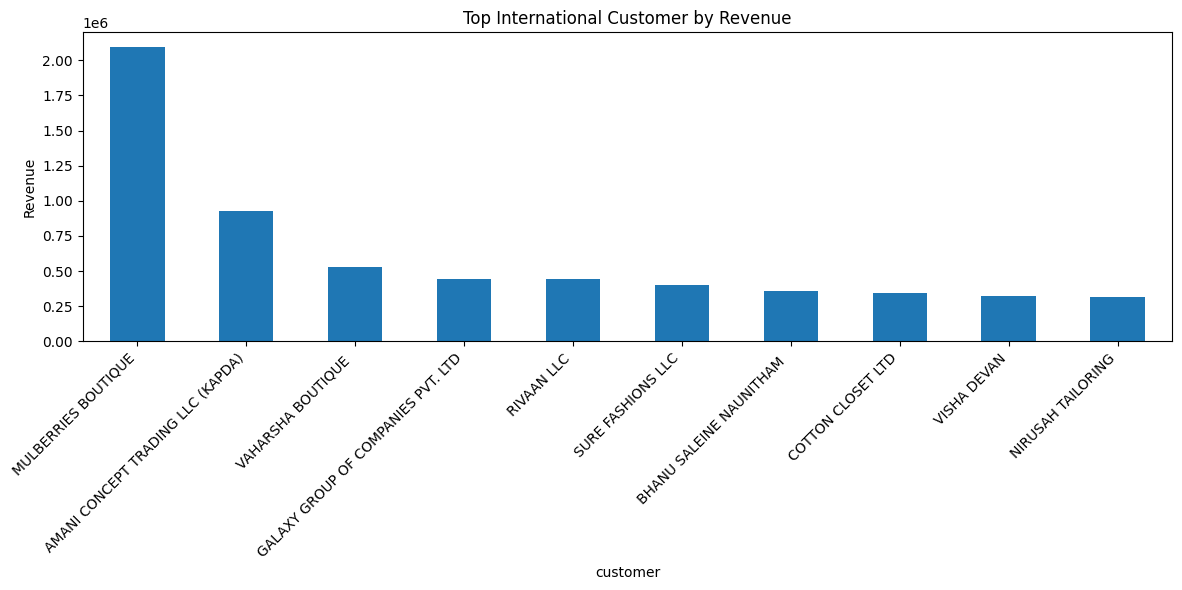

In [12]:
international.groupby("customer")["amount"].sum().sort_values(ascending = False).head(10).plot(
    kind = "bar",
    figsize =(12,6) 
)
plt.title("Top International Customer by Revenue")
plt.xlabel("customer")
plt.ylabel("Revenue")
plt.xticks(rotation = 45 , ha = "right")
plt.tight_layout()
plt.show()

In [13]:
customer_percent = ((customer_sales / customer_sales.sum())*100).round(2).astype(str) + "%"
customer_percent.head(10)  #astype converts number into string

customer
MULBERRIES BOUTIQUE                   33.87%
AMANI CONCEPT TRADING LLC (KAPDA)     15.05%
VAHARSHA BOUTIQUE                      8.53%
GALAXY GROUP OF COMPANIES PVT. LTD      7.2%
RIVAAN LLC                             7.17%
SURE FASHIONS LLC                      6.52%
BHANU SALEINE NAUNITHAM                5.77%
COTTON CLOSET LTD                      5.58%
VISHA DEVAN                            5.19%
NIRUSAH TAILORING                      5.12%
Name: amount, dtype: object

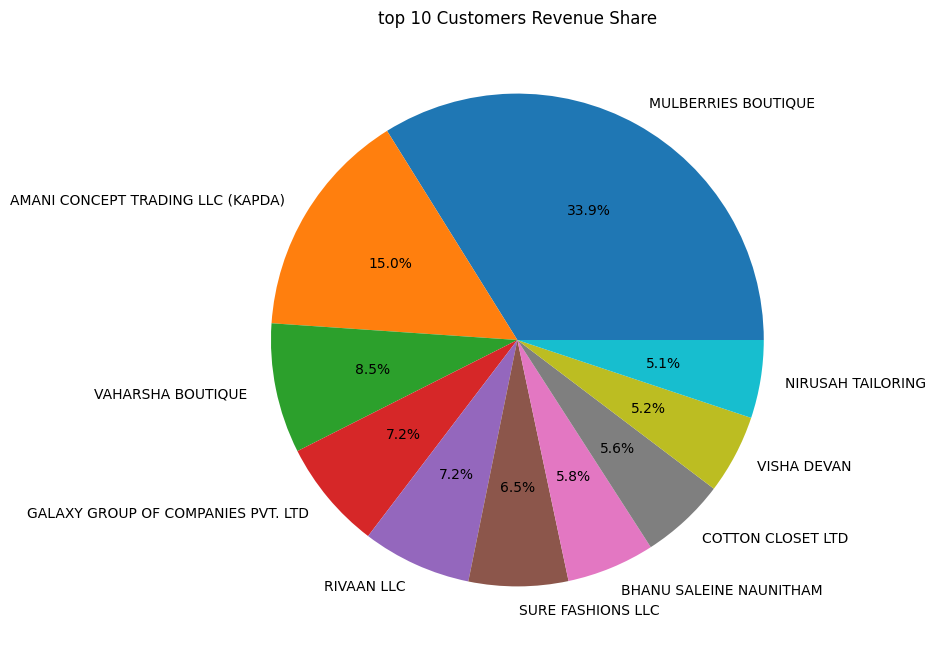

In [19]:
plt.figure(figsize =(8,8))

customer_sales.head(10).plot(
    kind = "pie",
    autopct = "%1.1f%%"
)
plt.title("top 10 Customers Revenue Share")
plt.ylabel("")
plt.show()

In [17]:
style_sales = international.groupby("style")["amount"].sum().sort_values(ascending = False)
style_sales.head(10)

style
SET268     215642.00
J0277      166201.00
J0242      132818.50
J0012      109461.43
SET252     104787.00
SET098     104029.00
SET110     102440.00
JNE3548     94873.50
J0230       93942.50
J0285       93121.00
Name: amount, dtype: float64

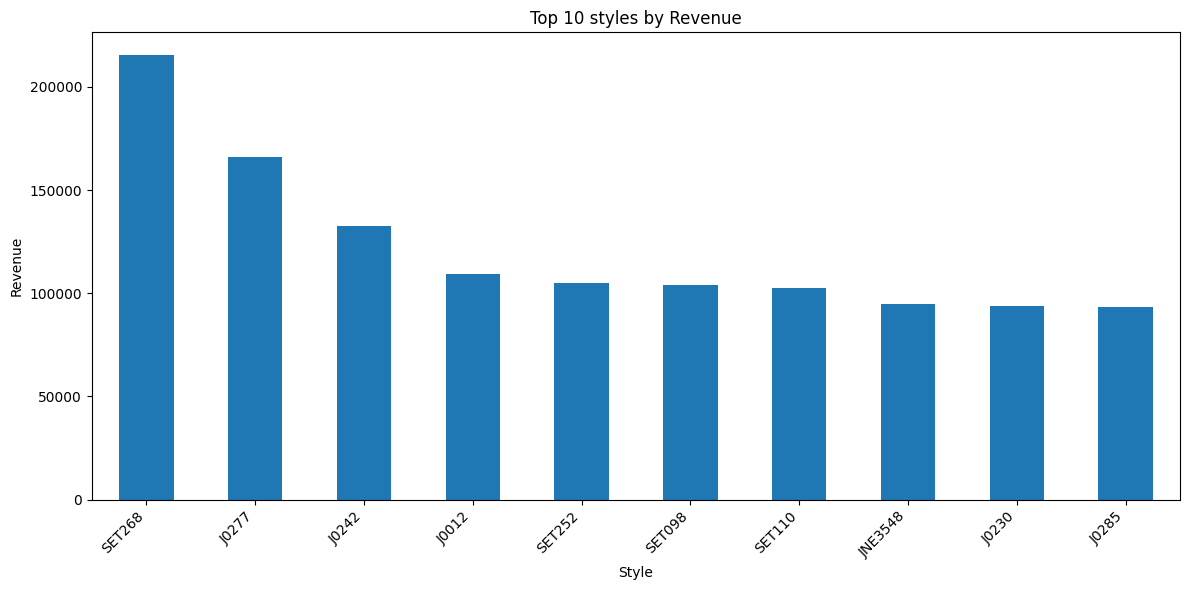

In [18]:
style_sales.head(10).plot(
    kind = "bar" ,figsize =(12,6))

plt.title("Top 10 styles by Revenue")
plt.xlabel("Style")
plt.ylabel("Revenue")
plt.xticks(rotation = 45 , ha = "right")
plt.tight_layout()
plt.show()


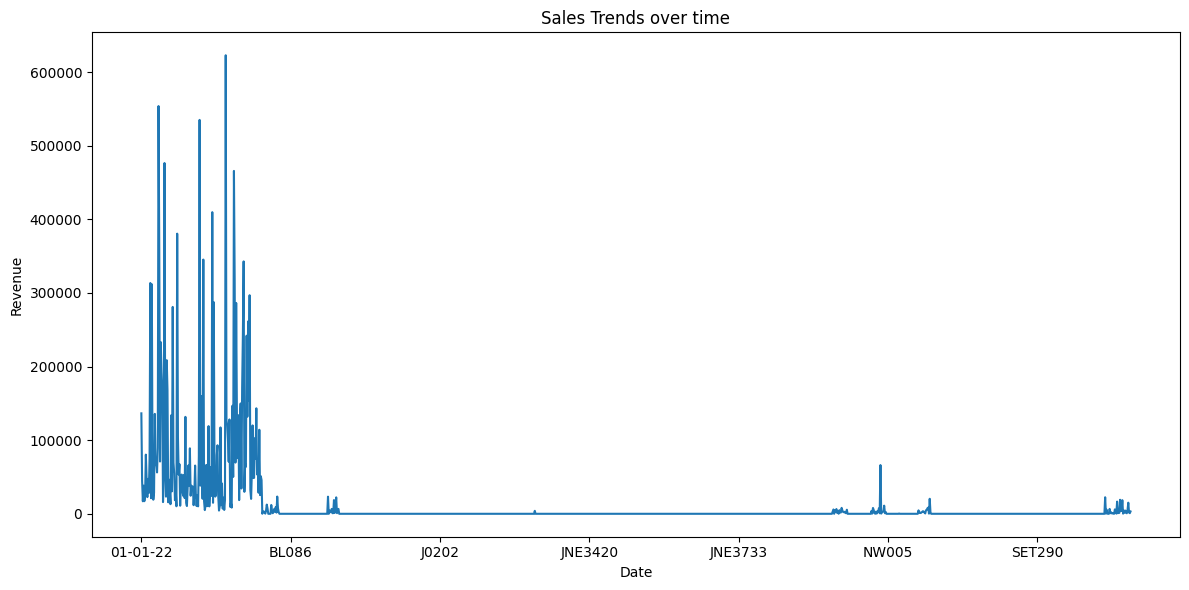

In [21]:
# checking sales trends
date_sales = international.groupby("date")["amount"].sum().sort_index()
date_sales.plot(kind = "line" , figsize = (12,6))

plt.title("Sales Trends over time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()